In [1]:
import pandas as pd

# --- STEP 1: Nigerian-Specific Commuting Emission Factors ---
factors = [
    {"commute_mode": "car_petrol", "unit": "km", "emission_factor": 0.225},
    {"commute_mode": "car_diesel", "unit": "km", "emission_factor": 0.201},
    {"commute_mode": "bus", "unit": "passenger-km", "emission_factor": 0.088},
    {"commute_mode": "motorbike", "unit": "km", "emission_factor": 0.112},
    {"commute_mode": "delivery_van", "unit": "km", "emission_factor": 0.315},
]

df_factors = pd.DataFrame(factors)
df_factors.to_csv("commute_emission_factors.csv", index=False)

print(" commute_emission_factors.csv created")
print(df_factors)


# --- STEP 2: Synthetic Business Commuting Data ---
# Assumptions:
# - Bakery staff use motorbikes and buses
# - Restaurant staff mostly use buses
# - Supermarket staff use cars, buses, vans (mixed)
# - Fuel stations use motorbikes + buses

commute_data = [
    {"business_id": "B0001", "business_type": "Bakery", "date": "2024-01",
     "commute_mode": "motorbike", "distance_km": 3200},
    {"business_id": "B0001", "business_type": "Bakery", "date": "2024-01",
     "commute_mode": "bus", "distance_km": 8200},

    {"business_id": "B0002", "business_type": "Restaurant", "date": "2024-01",
     "commute_mode": "bus", "distance_km": 10500},

    {"business_id": "B0003", "business_type": "Supermarket", "date": "2024-01",
     "commute_mode": "car_petrol", "distance_km": 5400},
    {"business_id": "B0003", "business_type": "Supermarket", "date": "2024-01",
     "commute_mode": "bus", "distance_km": 7600},
    {"business_id": "B0003", "business_type": "Supermarket", "date": "2024-01",
     "commute_mode": "delivery_van", "distance_km": 4200},

    {"business_id": "B0004", "business_type": "Fuel Station", "date": "2024-01",
     "commute_mode": "motorbike", "distance_km": 2800},
    {"business_id": "B0004", "business_type": "Fuel Station", "date": "2024-01",
     "commute_mode": "bus", "distance_km": 6900},
]

df_commute = pd.DataFrame(commute_data)
df_commute.to_csv("commute.csv", index=False)

print("\n commute.csv created")
yprint(df_commute.head())


 commute_emission_factors.csv created
   commute_mode          unit  emission_factor
0    car_petrol            km            0.225
1    car_diesel            km            0.201
2           bus  passenger-km            0.088
3     motorbike            km            0.112
4  delivery_van            km            0.315

 commute.csv created
  business_id business_type     date commute_mode  distance_km
0       B0001        Bakery  2024-01    motorbike         3200
1       B0001        Bakery  2024-01          bus         8200
2       B0002    Restaurant  2024-01          bus        10500
3       B0003   Supermarket  2024-01   car_petrol         5400
4       B0003   Supermarket  2024-01          bus         7600


In [2]:
import pandas as pd

# --- STEP 1: Load Data ---
commute = pd.read_csv("commute.csv")
factors = pd.read_csv("commute_emission_factors.csv")

# --- STEP 2: Merge with Emission Factors ---
def_commute = commute.merge(factors, how="left", on="commute_mode")

# --- STEP 3: Calculate Emissions ---
df_commute["emissions_kgCO2e"] = df_commute["distance_km"] * df_commute["emission_factor"]
e
# --- STEP 4: Save Output ---
df_commute.to_csv("commute_emissions_summary.csv", index=False)

print(" commute_emissions_summary.csv created with", len(df_commute), "rows")
print(df_commute.head(10))


 commute_emissions_summary.csv created with 8 rows
  business_id business_type     date  commute_mode  distance_km          unit  \
0       B0001        Bakery  2024-01     motorbike         3200            km   
1       B0001        Bakery  2024-01           bus         8200  passenger-km   
2       B0002    Restaurant  2024-01           bus        10500  passenger-km   
3       B0003   Supermarket  2024-01    car_petrol         5400            km   
4       B0003   Supermarket  2024-01           bus         7600  passenger-km   
5       B0003   Supermarket  2024-01  delivery_van         4200            km   
6       B0004  Fuel Station  2024-01     motorbike         2800            km   
7       B0004  Fuel Station  2024-01           bus         6900  passenger-km   

   emission_factor  emissions_kgCO2e  
0            0.112             358.4  
1            0.088             721.6  
2            0.088             924.0  
3            0.225            1215.0  
4            0.088      

In [3]:
sdf_commute.head((10))

,business_id,business_type,date,commute_mode,distance_km,unit,emission_factor,emissions_kgCO2e
0,B0001,Bakery,2024-01,motorbike,3200,km,0.112,358.4
1,B0001,Bakery,2024-01,bus,8200,passenger-km,0.088,721.6
2,B0002,Restaurant,2024-01,bus,10500,passenger-km,0.088,924.0
3,B0003,Supermarket,2024-01,car_petrol,5400,km,0.225,1215.0
4,B0003,Supermarket,2024-01,bus,7600,passenger-km,0.088,668.8
5,B0003,Supermarket,2024-01,delivery_van,4200,km,0.315,1323.0
6,B0004,Fuel Station,2024-01,motorbike,2800,km,0.112,313.6
7,B0004,Fuel Station,2024-01,bus,6900,passenger-km,0.088,607.2


In [4]:
from google.colab import files
files = files.download("commute_emissions_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Total emissions by business type:
 business_type
Supermarket     3206.8
Bakery          1080.0
Restaurant       924.0
Fuel Station     920.8
Name: emissions_kgCO2e, dtype: float64


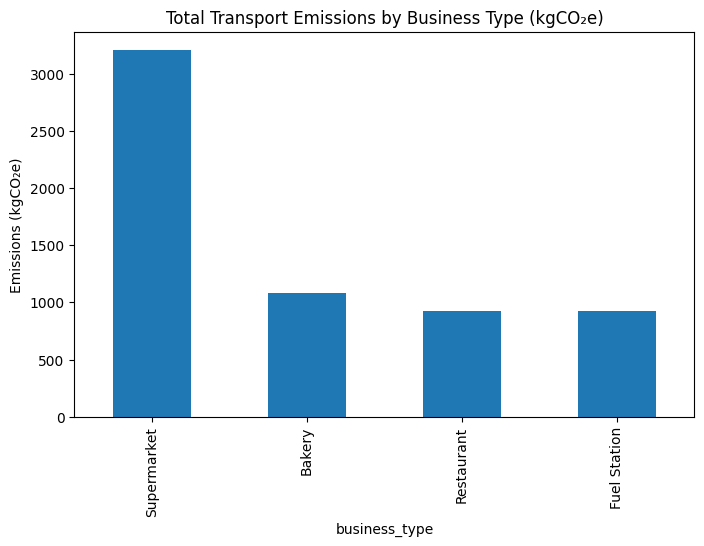

In [8]:
import matplotlib.pyplot as plt

emissions_by_biz = df_commute.groupby("business_type")["emissions_kgCO2e"].sum().sort_values(ascending=False)
print("\nTotal emissions by business type:\n", emissions_by_biz)

emissions_by_biz.plot(kind="bar", figsize=(8,5), title="Total Transport Emissions by Business Type (kgCO₂e)")
plt.ylabel("Emissions (kgCO₂e)")
plt.show()
